In [4]:
ls

acti_df_100ms_1core.csv        kourier_10ms_1core.csv
acti_df_100ms.csv              kourier_10ms.csv
acti_df_10ms_1core.csv         kourier_2ms_1core.csv
acti_df_10ms.csv               kourier_2ms.csv
acti_df_2ms_1core.csv          kourier_35s_1core.csv
acti_df_2ms.csv                kourier_35s.csv
acti_df_35s_1core.csv          kourier_50ms_1core.csv
acti_df_35s.csv                kourier_50ms.csv
acti_df_50ms_1core.csv         latency_figure.pdf
acti_df_50ms.csv               scheduler_times-100ms_1core.csv
all_data_100ms_1core.csv       scheduler_times-100ms_1raspberry.csv
all_data_100ms_1raspberry.csv  scheduler_times-100ms.csv
all_data_100ms.csv             scheduler_times-10ms_1core.csv
all_data_10ms_1core.csv        scheduler_times-10ms_1raspberry.csv
all_data_10ms_1raspberry.csv   scheduler_times-10ms.csv
all_data_10ms.csv              scheduler_times-2ms_1core.csv
all_data_2ms_1core.csv         scheduler_times-2ms_1raspberry.csv
all_data_2ms_1raspberry.csv    scheduler_times

Chargement end-to-end...
Chargement scheduler...

Figure sauvegardée : latency_figure.pdf


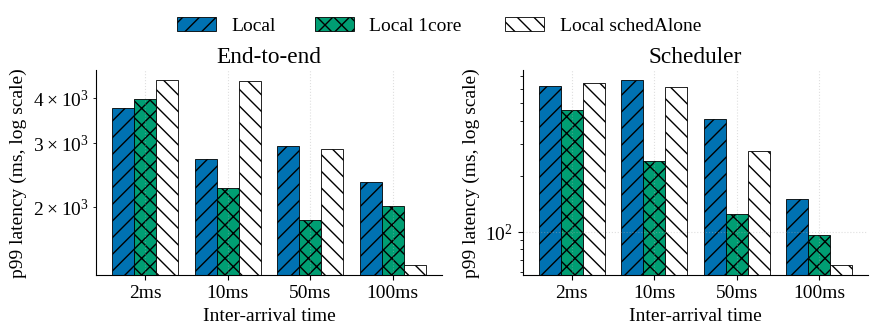

In [40]:
"""
Deux subplots, style ACPC (Times New Roman, palette Wong 2011, hachures,
pas de spines haut/droit) :
  - subplot 1 : latence end-to-end p99 (ms), colonne 'latency_s' (déjà en ms)
  - subplot 2 : latence scheduler p99 (ms), colonne 'scheduling_time_ms'
Mêmes délais, mêmes configs, sur les deux subplots.
"""
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────
# CONFIGURATION -- à adapter
# ─────────────────────────────────────────────────────


class args:
    data_dir = "."                       # dossier contenant tous les CSV
    delays = ["2ms", "10ms", "50ms", "100ms"]
    output = "latency_figure.pdf"


# Un config = un suffixe de fichier pour chaque famille (end-to-end / scheduler).
# {delay} est remplacé par chaque valeur de args.delays.
CONFIGS = [
    {
        "label": "Local",
        "e2e_pattern": "all_data_{delay}.csv",
        "sched_pattern": "scheduler_times-{delay}.csv",
        "color": "#0072B2",   # bleu Wong
        "hatch": "//",
    },
    {
        "label": "Local 1core ",
        "e2e_pattern": "all_data_{delay}_1core.csv",
        "sched_pattern": "scheduler_times-{delay}_1core.csv",
        "color": "#009E73",   # orange Wong
        "hatch": "xx",
    },
    {
        "label": "Local schedAlone",
        "e2e_pattern": "all_data_{delay}_1raspberry.csv",
        "sched_pattern": "scheduler_times-{delay}_1raspberry.csv",
        "color": "white",   # vert Wong
        "hatch": "\\\\",
    },
]



E2E_COLUMN = "latency_s"           # déjà en ms malgré le nom
SCHED_COLUMN = "scheduling_time_ms"
PERCENTILE = 99

# ─────────────────────────────────────────────────────
# STYLE (Times New Roman, no top/right spines, palette Wong 2011)
# ─────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "Nimbus Roman", "DejaVu Serif"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.4,
    "font.size": 14,
})


# ─────────────────────────────────────────────────────
# LECTURE DES DONNÉES
# ─────────────────────────────────────────────────────
def load_p99(pattern, delay, column):
    path = os.path.join(args.data_dir, pattern.format(delay=delay))
    matches = glob.glob(path)
    if not matches:
        print(f"  [absent] {path}")
        return np.nan
    df = pd.read_csv(matches[0])
    if column not in df.columns:
        print(f"  [colonne '{column}' absente dans {matches[0]}]")
        return np.nan
    return np.percentile(df[column].dropna(), PERCENTILE)


def collect(pattern_key, column):
    data = {cfg["label"]: [] for cfg in CONFIGS}
    for delay in args.delays:
        for cfg in CONFIGS:
            data[cfg["label"]].append(load_p99(cfg[pattern_key], delay, column))
    return data


print("Chargement end-to-end...")
e2e_data = collect("e2e_pattern", E2E_COLUMN)
print("Chargement scheduler...")
sched_data = collect("sched_pattern", SCHED_COLUMN)

# ─────────────────────────────────────────────────────
# PLOT
# ─────────────────────────────────────────────────────
n_delays = len(args.delays)
n_configs = len(CONFIGS)
x = np.arange(n_delays)
bar_width = 0.8 / n_configs

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

for ax, data, title, ylabel in [
    (axes[0], e2e_data, "End-to-end", "p99 latency (ms, log scale)"),
    (axes[1], sched_data, "Scheduler", "p99 latency (ms, log scale)"),
]:
    for i, cfg in enumerate(CONFIGS):
        offset = (i - (n_configs - 1) / 2) * bar_width
        ax.bar(x + offset, data[cfg["label"]], width=bar_width,
               label=cfg["label"], color=cfg["color"], hatch=cfg["hatch"],
               edgecolor="black", linewidth=0.6)
    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels(args.delays)
    ax.set_xlabel("Inter-arrival time")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=n_configs,
           bbox_to_anchor=(0.5, 1.08), frameon=False)

fig.tight_layout()
fig.savefig(args.output, bbox_inches="tight", dpi=300)
print(f"\nFigure sauvegardée : {args.output}")